# Практическая работа №5: Элементы регрессионного анализа. Выборочные прямые среднеквадратической регрессии. Корреляционные отношения

Выполнили студенты гр. 2384 Федоров Михаил и Муравин Егор. Вариант №30

## Цель работы

Ознакомление с основными положениями метода наименьших квадратов (МНК), со статистическими свойствами МНК-оценок, с понятием функции регрессии и роли МНК в регрессионном анализе, с корреляционным отношением, как мерой тесноты произвольной (в том числе и линейной) корреляционной связи.

## Постановка задачи

Для заданной двумерной выборки (x, y) построить уравнения выборочных прямых среднеквадратической регрессии. Полученные линейные функции регрессии отобразить графически. Найти выборочное корреляционное отношение. Полученные результаты содержательно проинтерпретировать.

## Основные теоретические положения


Регрессия $Y$ на $X$:

$$\hat{y} = b_0 + b_1 x$$

$$b_1 = \frac{\text{cov}(x, y)}{D_x} = \frac{\overline{xy} - \bar{x} \cdot \bar{y}}{\overline{x^2} - \bar{x}^2}, \quad b_0 = \bar{y} - b_1 \bar{x}$$

Регрессия $X$ на $Y$:

$$\hat{x} = a_0 + a_1 y$$

$$a_1 = \frac{\text{cov}(x, y)}{D_y} = \frac{\overline{xy} - \bar{x} \cdot \bar{y}}{\overline{y^2} - \bar{y}^2}, \quad a_0 = \bar{x} - a_1 \bar{y}$$

Корреляционное отношение $Y$ на $X$:

$$\eta_{yx}^2 = \frac{\sum\limits_{j=1}^{k_x} n_{x_j}(\bar{y}_j - \bar{y})^2}{\sum\limits_{j=1}^{k_x} \sum\limits_{i=1}^{k_y} n_{ij}(y_i - \bar{y})^2}$$

где $\bar{y}_j = \frac{1}{n_{x_j}} \sum\limits_{i=1}^{k_y} n_{ij} \cdot y_i$ - условное среднее $Y$ при фиксированном $x_j$.

Аналогично определяется $\eta_{xy}$.



### Параболическая регрессия

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2$$

Коэффициенты находятся из системы нормальных уравнений МНК:

$$\begin{cases} n\beta_0 + \beta_1 \sum x_i + \beta_2 \sum x_i^2 = \sum y_i \\ \beta_0 \sum x_i + \beta_1 \sum x_i^2 + \beta_2 \sum x_i^3 = \sum x_i y_i \\ \beta_0 \sum x_i^2 + \beta_1 \sum x_i^3 + \beta_2 \sum x_i^4 = \sum x_i^2 y_i \end{cases}$$

### Дробно-рациональная функция

$$y = \frac{x}{\beta_0 + \beta_1 x}$$

Линеаризация: $\frac{1}{y} = \frac{\beta_0}{x} + \beta_1$, то есть при замене $Y' = \frac{1}{y}$, $X' = \frac{1}{x}$ получаем линейную зависимость $Y' = \beta_0 X' + \beta_1$, к которой применим стандартный МНК.

### Показатели качества регрессии

**Коэффициент детерминации:**

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

**Средняя квадратическая ошибка:**

$$S_\varepsilon = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

**Средняя ошибка аппроксимации:**

$$A = \frac{1}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right| \cdot 100\%$$

## Выполнение работы


1. Отобразить двумерную выборку на графике.

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [154]:
df = pd.read_csv("data_1.csv", sep=",")
df.rename(columns={"nu": "relative_weight", "E": "simplicity"}, inplace=True)
df = df.sample(n=118, random_state=1)

x = df["relative_weight"].values
y = df["simplicity"].values
n = len(x)


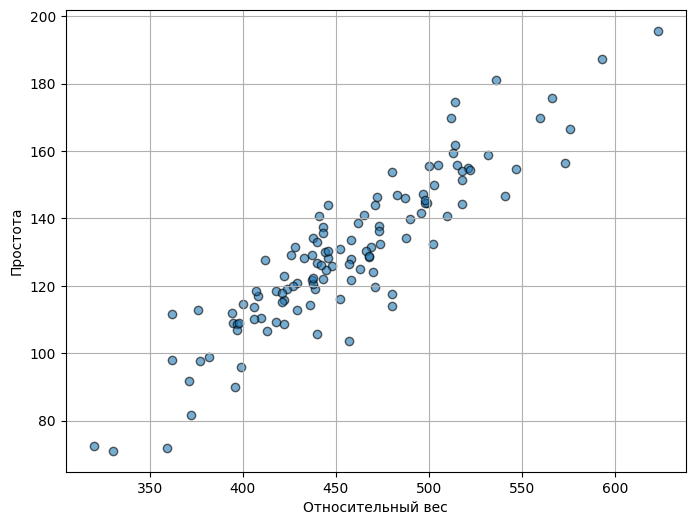

In [155]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6, edgecolors="k")
plt.xlabel("Относительный вес")
plt.ylabel("Простота")
plt.grid(True)
plt.show()

2. Для заданной выборки построить уравнения средней квадратичной регрессии x на y и y на x соответственно. Построить полученные прямые на множестве выборки. Объяснить результаты.

In [156]:
def build_intervals_row(data):
    x_min = data.min()
    x_max = data.max()
    n = len(data)
    k = math.ceil(1 + 3.322 * math.log10(n))
    h = (x_max - x_min) / k

    boundaries = [x_min]
    for _ in range(k):
        boundaries.append(round(boundaries[-1] + h, 2))
    if boundaries[-1] < x_max:
        boundaries.append(round(boundaries[-1] + h, 2))

    counts, edges = np.histogram(data, bins=boundaries)
    midpoints = (edges[:-1] + edges[1:]) / 2

    return midpoints, counts, edges, h, n, k


def compute_all_statistics(data):
    midpoints, counts, edges, h, n, k = build_intervals_row(data)
    x_bar = np.average(midpoints, weights=counts)
    modal_idx = np.argmax(counts)
    C = midpoints[modal_idx]
    u = (midpoints - C) / h
    M1_star = np.sum(counts * u) / n
    M2_star = np.sum(counts * u**2) / n
    M3_star = np.sum(counts * u**3) / n
    M4_star = np.sum(counts * u**4) / n
    m2 = (M2_star - M1_star**2) * h**2
    m3 = (M3_star - 3 * M2_star * M1_star + 2 * M1_star**3) * h**3
    m4 = (M4_star - 4 * M3_star * M1_star + 6 * M2_star * M1_star**2 - 3 * M1_star**4) * h**4
    D = np.average((midpoints - x_bar)**2, weights=counts)
    sigma = np.sqrt(D)
    s2 = D * n / (n - 1)
    s = np.sqrt(s2)
    A_s = m3 / sigma**3
    E_k = m4 / sigma**4 - 3
    f_m = counts[modal_idx]
    f_m_minus = counts[modal_idx - 1] if modal_idx > 0 else 0
    f_m_plus = counts[modal_idx + 1] if modal_idx < len(counts) - 1 else 0
    x_m = edges[modal_idx]
    denom = (f_m - f_m_minus) + (f_m - f_m_plus)
    Mo = x_m + h * (f_m - f_m_minus) / denom if denom != 0 else x_m
    cumulative = 0
    me_idx = 0
    for i, c in enumerate(counts):
        cumulative += c
        if cumulative >= n / 2:
            me_idx = i
            break
    S_me_minus = cumulative - counts[me_idx]
    Me = edges[me_idx] + h * (n / 2 - S_me_minus) / counts[me_idx]
    V = (sigma / x_bar) * 100
    return {
        "n": n, "k": k, "h": round(h, 4),
        "x_bar": round(x_bar, 4), "D": round(D, 4), "s2": round(s2, 4),
        "sigma": round(sigma, 4), "s": round(s, 4),
        "A_s": round(A_s, 4), "E_k": round(E_k, 4),
        "Mo": round(Mo, 4), "Me": round(Me, 4), "V": round(V, 2),
        "midpoints": midpoints, "counts": counts, "edges": edges, "C": C,
    }


statistics_rw = compute_all_statistics(x)
statistics_s = compute_all_statistics(y)

In [157]:
# Регрессия y на x

x_mean = np.mean(x)
y_mean = np.mean(y)
cov_xy = np.cov(x, y, ddof=0)[0, 1] 
var_x = np.var(x, ddof=0)
var_y = np.var(y, ddof=0)

b1_yx = cov_xy / var_x
b0_yx = y_mean - b1_yx * x_mean

print(f"y_hat = {b0_yx:.6f} + {b1_yx:.6f} * x")

y_hat = -44.975664 + 0.383040 * x


In [158]:
# Регрессия x на y
b1_xy = cov_xy / var_y
b0_xy = x_mean - b1_xy * y_mean

print(f"x_hat = {b0_xy:.6f} + {b1_xy:.6f} * y")

x_hat = 175.108077 + 2.166043 * y


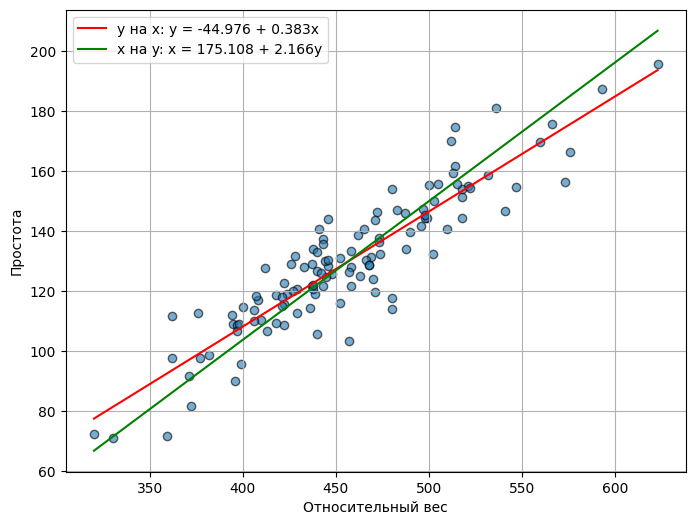

In [159]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6, edgecolors="k")

x_line = np.linspace(x.min(), x.max(), 1000)
y_line_yx = b0_yx + b1_yx * x_line
plt.plot(x_line, y_line_yx, "r-", label=f"y на x: y = {b0_yx:.3f} + {b1_yx:.3f}x")

y_line_xy = (x_line - b0_xy) / b1_xy
plt.plot(x_line, y_line_xy, "g-", label=f"x на y: x = {b0_xy:.3f} + {b1_xy:.3f}y")

plt.xlabel("Относительный вес")
plt.ylabel("Простота")
plt.legend()
plt.grid(True)
plt.show()

### Вывод
Обе прямые проходят через точку средних $(\bar{x}, \bar{y})$. Прямые не совпадают, так как минимизируют разные суммы квадратов отклонений (по разным осям). Угол между прямыми определяется величиной коэффициента корреляции: чем ближе $|r_{xy}|$ к единице, тем меньше угол между прямыми. В нашем случае прямые расположены достаточно близко друг к другу, что свидетельствует о сильной линейной связи между признаками.

3. Составить корреляционную таблицу для нахождения выборочного корреляционного отношения. Убедиться, что неравенства $\eta_{xy} \geq |r_{xy}|$ и $\eta_{yx} \geq |r_{xy}|$ выполняются.

In [160]:
edges_rw = statistics_rw["edges"]
edges_s = statistics_s["edges"]
midpoints_rw = statistics_rw["midpoints"]
midpoints_s = statistics_s["midpoints"]

k_x = len(edges_rw) - 1
k_y = len(edges_s) - 1

freq_matrix = np.zeros((k_y, k_x), dtype=int)

for xi, yi in zip(x, y):
    ix = np.searchsorted(edges_rw, xi, side="right") - 1
    ix = min(ix, k_x - 1)
    ix = max(ix, 0)
    iy = np.searchsorted(edges_s, yi, side="right") - 1
    iy = min(iy, k_y - 1)
    iy = max(iy, 0)
    freq_matrix[iy, ix] += 1

n_x_marg = np.sum(freq_matrix, axis=0)
n_y_marg = np.sum(freq_matrix, axis=1)

In [161]:
corr_table = pd.DataFrame(freq_matrix, index=[f"{m:.2f}" for m in midpoints_s], columns=[f"{m:.2f}" for m in midpoints_rw])
corr_table["n_y"] = corr_table.sum(axis=1)
corr_table.loc["n_x"] = corr_table.sum(axis=0)
corr_table.index.name = "simplicity"        
corr_table.columns.name = "relative_weight" 
corr_table


relative_weight,338.94,376.82,414.70,452.58,490.46,528.34,566.22,604.10,n_y
simplicity,,,,,,,,,
78.89,2,2,0,0,0,0,0,0,4
94.47,0,4,2,0,0,0,0,0,6
110.05,0,4,14,4,2,0,0,0,24
125.63,0,0,11,25,2,0,0,0,38
141.20,0,0,0,9,12,3,0,0,24
156.78,0,0,0,0,4,9,1,0,14
172.35,0,0,0,0,0,2,3,0,5
187.93,0,0,0,0,0,1,0,2,3
n_x,2,10,27,38,20,15,4,2,118


In [162]:
y_bar_table = np.sum(n_y_marg * midpoints_s) / n

y_cond_means = np.zeros(k_x)
for j in range(k_x):
    if n_x_marg[j] > 0:
        y_cond_means[j] = np.sum(freq_matrix[:, j] * midpoints_s) / n_x_marg[j]

S_between_yx = np.sum(n_x_marg * (y_cond_means - y_bar_table)**2)

S_total_y = 0
for j in range(k_x):
    for i in range(k_y):
        S_total_y += freq_matrix[i, j] * (midpoints_s[i] - y_bar_table)**2

eta_yx_sq = S_between_yx / S_total_y
eta_yx = np.sqrt(eta_yx_sq)


print(f"η_yx = {eta_yx:.6f}")

η_yx = 0.890694


In [163]:
x_bar_table = np.sum(n_x_marg * midpoints_rw) / n

x_cond_means = np.zeros(k_y)
for i in range(k_y):
    if n_y_marg[i] > 0:
        x_cond_means[i] = np.sum(freq_matrix[i, :] * midpoints_rw) / n_y_marg[i]

S_between_xy = np.sum(n_y_marg * (x_cond_means - x_bar_table)**2)

S_total_x = 0
for i in range(k_y):
    for j in range(k_x):
        S_total_x += freq_matrix[i, j] * (midpoints_rw[j] - x_bar_table)**2

eta_xy_sq = S_between_xy / S_total_x
eta_xy = np.sqrt(eta_xy_sq)

print(f"η_xy = {eta_xy:.6f}")

η_xy = 0.891638


In [164]:
x_mean_tab = np.average(midpoints_rw, weights=n_x_marg)
y_mean_tab = np.average(midpoints_s, weights=n_y_marg)

cov_xy_tab = 0
for iy in range(k_y):
    for ix in range(k_x):
        cov_xy_tab += freq_matrix[iy, ix] * (midpoints_rw[ix] - x_mean_tab) * (midpoints_s[iy] - y_mean_tab)
var_x_tab = np.sum(n_x_marg * (midpoints_rw - x_mean_tab)**2)
var_y_tab = np.sum(n_y_marg * (midpoints_s - y_mean_tab)**2)
r_tab = cov_xy_tab / np.sqrt(var_x_tab * var_y_tab)

print(f"η_yx >= |r_xy|: {eta_yx:.6f} >= {abs(r_tab):.6f}: {eta_yx >= abs(r_tab) - 1e-10}")
print(f"η_xy >= |r_xy|: {eta_xy:.6f} >= {abs(r_tab):.6f}: {eta_xy >= abs(r_tab) - 1e-10}")

η_yx >= |r_xy|: 0.890694 >= 0.887289: True
η_xy >= |r_xy|: 0.891638 >= 0.887289: True


4. Для заданной выборки построить корреляционную кривую параболического вида $y = \beta_0 + \beta_1 x + \beta_2 x^2$, сделать выводы.

In [165]:
beta2, beta1, beta0 = np.polyfit(x, y, 2)

print(f"y = {beta0:.6f} + {beta1:.6f}·x + {beta2:.6f}·x^2")


y = -84.793106 + 0.556851·x + -0.000187·x^2


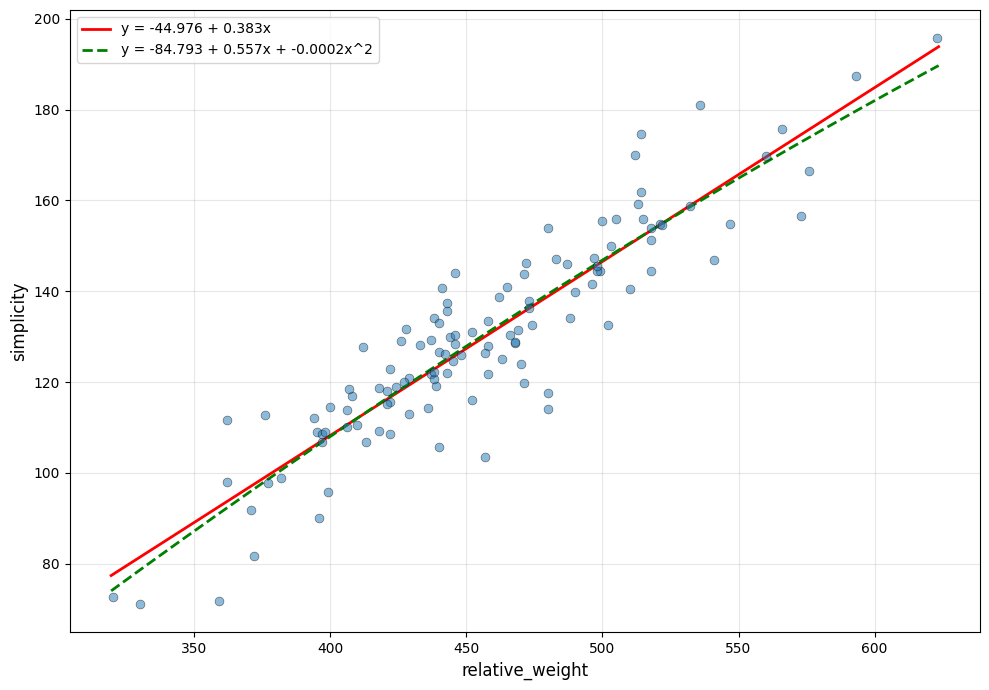

In [166]:
x_plot = np.linspace(x.min() - 0.5, x.max() + 0.5, 1000)

plt.figure(figsize=(10, 7))
plt.scatter(x, y, alpha=0.5, edgecolors="k", linewidths=0.5, s=40, zorder=3)
plt.plot(x_plot, b0_yx + b1_yx * x_plot, "r-", linewidth=2,
         label=f"y = {b0_yx:.3f} + {b1_yx:.3f}x")
plt.plot(x_plot, np.polyval((beta2, beta1, beta0), x_plot), "g--", linewidth=2,
         label=f"y = {beta0:.3f} + {beta1:.3f}x + {beta2:.4f}x^2")
plt.xlabel("relative_weight", fontsize=12)
plt.ylabel("simplicity", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Вывод
Коэффициент при $x^2$ имеет очень малое абсолютное значение, из чего следует, что квадратичная зависимость слабая.
Это согласуется с ранее полученным результатом: близость корреляционных отношений $\eta$ к модулю коэффициента корреляции $|r_{xy}|$ свидетельствовала о линейном характере связи. 
В таком случае применение параболической модели избыточно. 

5. Для заданной выборки построить корреляционную кривую в зависимости от номера варианта и сделать выводы:
    + дробно-рациональная функция: $y = \frac{x}{\beta_0 + \beta_1 x}$.

Преобразуем к линейному виду:

$$ \frac{1}{y} = \frac{\beta_0 + \beta_1 x}{x} = \frac{\beta_0}{x} + \beta_1 $$

$ y` = \frac{1}{y}, \quad x` = \frac{1}{x} $


$$ y` = \beta_0 x` + \beta_1 $$



In [167]:
X_prime = 1.0 / x 
Y_prime = 1.0 / y

coeffs_frac = np.polyfit(X_prime, Y_prime, 1)
beta0_frac = coeffs_frac[0]
beta1_frac = coeffs_frac[1]

print(f"y = x / ({beta0_frac:.6f} + {beta1_frac:.6f} · x)")

y = x / (5.253437 + -0.003711 · x)


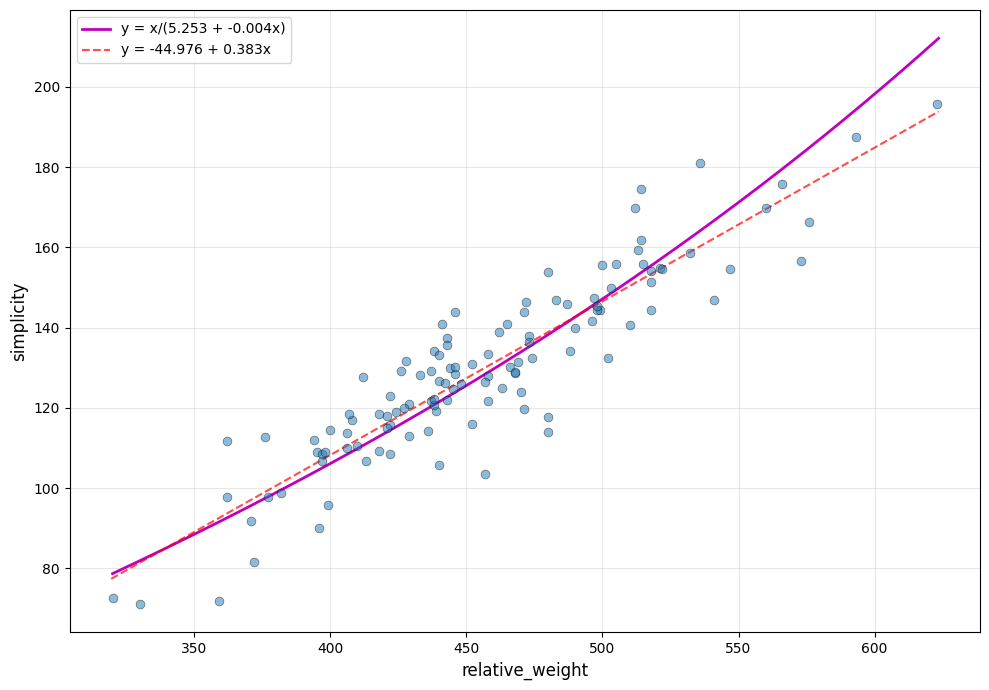

In [168]:
x_plot_frac = np.linspace(max(x.min(), 0.01), x.max() + 0.5, 1000)
y_plot_frac = x_plot_frac / (beta0_frac + beta1_frac * x_plot_frac)

plt.figure(figsize=(10, 7))
plt.scatter(x, y, alpha=0.5, edgecolors="k", linewidths=0.5, s=40, zorder=3)
plt.plot(x_plot_frac, y_plot_frac, "m-", linewidth=2,
         label=f"y = x/({beta0_frac:.3f} + {beta1_frac:.3f}x)")
plt.plot(x_plot, b0_yx + b1_yx * x_plot, "r--", linewidth=1.5, alpha=0.7,
         label=f"y = {b0_yx:.3f} + {b1_yx:.3f}x")
plt.xlabel("relative_weight", fontsize=12)
plt.ylabel("simplicity", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Вывод
Применение дробно-рациональной функции так же не дало особых улучшений, даже ухудшила показали модели. Данный пример вновь демонстрирует линейный характер.


6. Дополнительное необходимое задание: Вычислить следующие показатели качества регрессии для каждой кривой и сделать выводы:
   + теоретический коэффициент детерминации $R^2$;
   + средняя квадратическая ошибка $S_e$;
   + средняя ошибка аппроксимации (приближения) $A$.

In [169]:
# Линейная модель
y_pred_lin = b0_yx + b1_yx * x
rss_lin = np.sum((y - y_pred_lin) ** 2)
tss = np.sum((y - np.mean(y)) ** 2)

# Коэффициент детерминации
r_squared_lin = 1 - rss_lin / tss

# Стандартная ошибка регрессии
std_error_lin = np.sqrt(rss_lin / n)

# Средняя абсолютная процентная ошибка
mape_lin = np.mean(np.abs((y - y_pred_lin) / y)) * 100


# Параболическая модель
y_pred_poly = np.polyval((beta2, beta1, beta0), x)
rss_poly = np.sum((y - y_pred_poly) ** 2)

# Коэффициент детерминации
r_squared_poly = 1 - rss_poly / tss

# Стандартная ошибка регрессии
std_error_poly = np.sqrt(rss_poly / n)

# Средняя абсолютная процентная ошибка
mape_poly = np.mean(np.abs((y - y_pred_poly) / y)) * 100


# Дробно-рациональная модель
y_pred_frac = x / (beta0_frac + beta1_frac * x)
rss_frac = np.sum((y - y_pred_frac) ** 2)

# Коэффициент детерминации
r_squared_frac = 1 - rss_frac / tss

# Стандартная ошибка регрессии
std_error_frac = np.sqrt(rss_frac / len(x))

# Средняя абсолютная процентная ошибка
mape_frac = np.mean(np.abs((y - y_pred_frac) / y)) * 100


quality_table = pd.DataFrame({
    "Модель": ["Линейная", "Параболическая", "Дробно-рациональная"],
    "Уравнение": [
        f"y = {b0_yx:.4f} + {b1_yx:.4f}·x",
        f"y = {beta0:.4f} + {beta1:.4f}·x + {beta2:.6f}·x^2",
        f"y = x / ({beta0_frac:.4f} + {beta1_frac:.4f}·x)"
    ],
    "R^2": [round(r_squared_lin, 6), round(r_squared_poly, 6), round(r_squared_frac, 6)],
    "S_ε": [round(std_error_lin, 6), round(std_error_poly, 6), round(std_error_frac, 6)],
    "MAPE, %": [round(mape_lin, 2), round(mape_poly, 2), round(mape_frac, 2)]
})
quality_table

,Модель,Уравнение,R^2,S_ε,"MAPE, %"
0,Линейная,y = -44.9757 + 0.3830·x,0.829680,9.409018,5.77
1,Параболическая,y = -84.7931 + 0.5569·x + -0.000187·x^2,0.830961,9.373590,5.71
2,Дробно-рациональная,y = x / (5.2534 + -0.0037·x),0.805528,10.054030,6.23


### Вывод
Линейная модель обеспечивает хорошее качество аппроксимации. Коэффициент детерминации показывает, что модель объясняет около 83% вариации зависимой переменной. Средняя ошибка аппроксимации, свидетельствует о приемлемой точности модели.

Параболическая модель даёт незначительное улучшение по сравнению с линейной: прирост $R^2$ составляет лишь 0.0013, а средняя ошибка аппроксимации уменьшилась всего на 0.06 п.п. Столь малое улучшение при усложнении модели подтверждает, что зависимость между признаками практически линейна, и введение дополнительного параметра не оправдано.

Дробно-рациональная модель показала худшие результаты среди всех рассмотренных моделей. Форма модели наименьшим образом подходит под данный вид данных.

Таким образом, линейная модель является оптимальной для описания зависимости между относительным весом и простотой: она обеспечивает хорошее качество аппроксимации при минимальном числе параметров.

## Выводы
В ходе работы была визуализирована двумерная выборка, по которой можно наблюдать линейную зависимость данных. Были построены уравнения среднеквадратической регрессии $X$ на $Y$ и $Y$ на $X$. Обе прямые проходят через точку средних $(\bar{x}, \bar{y})$ и расположены близко друг к другу, что свидетельствует о сильной линейной связи. Однако прямые различаются между собой, так как минимизируют разные суммы квадратов отклонений (по разным осям). Составлена корреляционная таблица, вычислены корреляционные отношения $\eta_{yx}$ и $\eta_{xy}$. Подтверждено выполнение неравенств $\eta_{yx} \geqslant |r_{xy}|$ и $\eta_{xy} \geqslant |r_{xy}|$. Построены параболическая и дробно-рациональная модели. Сравнение показателей качества ($R^2$, $S_\varepsilon$, $A$) трёх моделей показало, что линейная регрессия является наиболее адекватной и оптимальной моделью для описания зависимости между исследуемыми признаками, обеспечивая хорошую точность при минимальной сложности. Параболическая модель также показала неплохие результаты, однако её использование может быть избыточным, поскольку прирост качества аппроксимации ничтожно мал. Дробно-рациональная модель имеет наименее подходящую форму для описания данных и показала худшие результаты по всем критериям качества.
